Testing Page size: 1
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 1 KB)

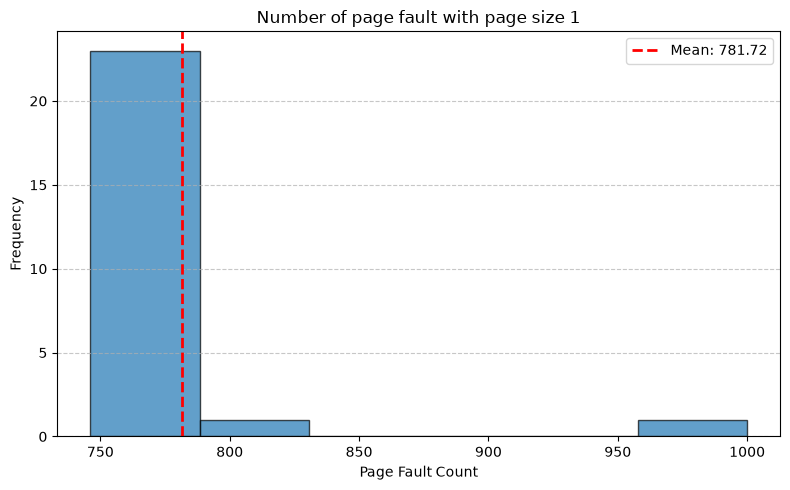

Testing Page size: 2
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 2 KB)

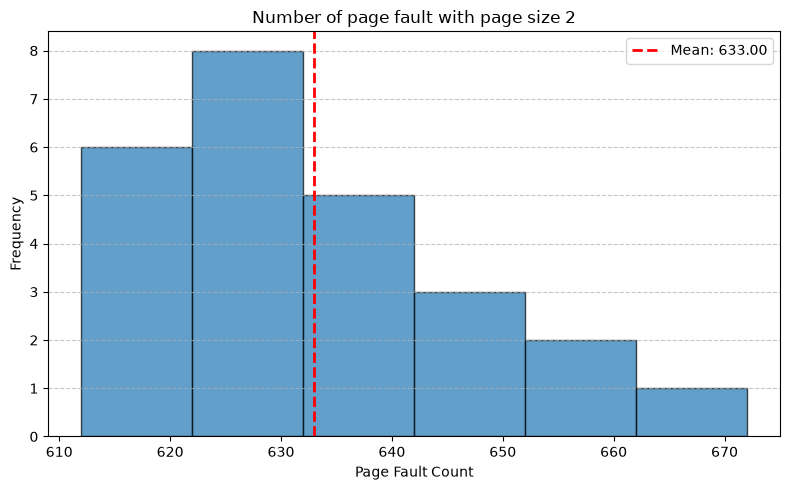

Testing Page size: 4
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 4 KB)

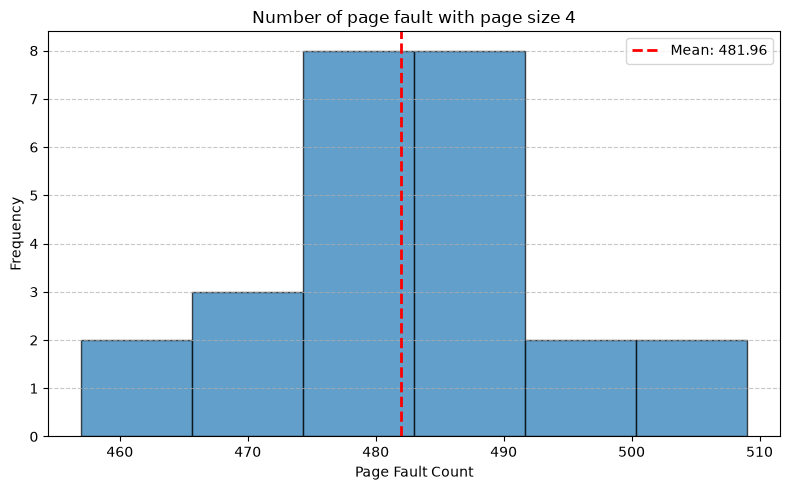

Testing Page size: 8
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 8 KB)

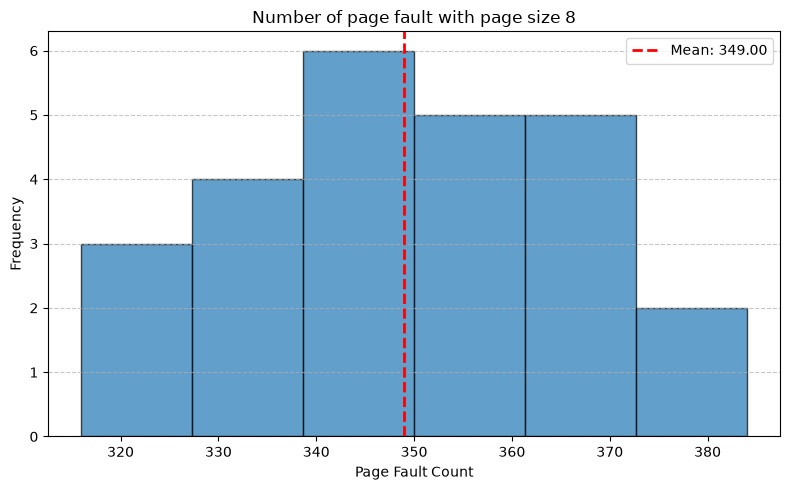

Testing Page size: 12
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 12 KB)

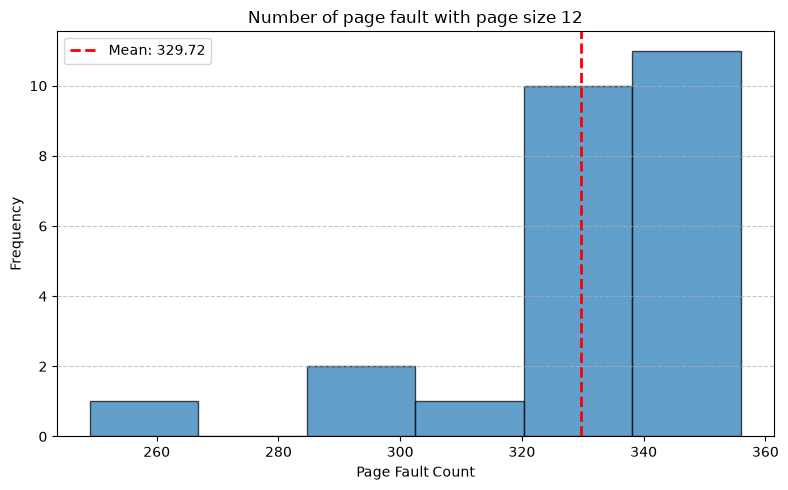

Testing Page size: 16
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 16 KB)

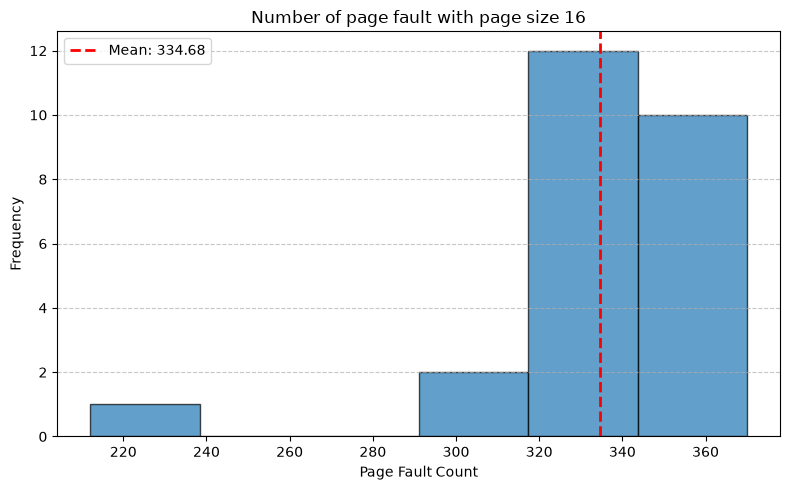

Testing Page size: 20
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 20 KB)

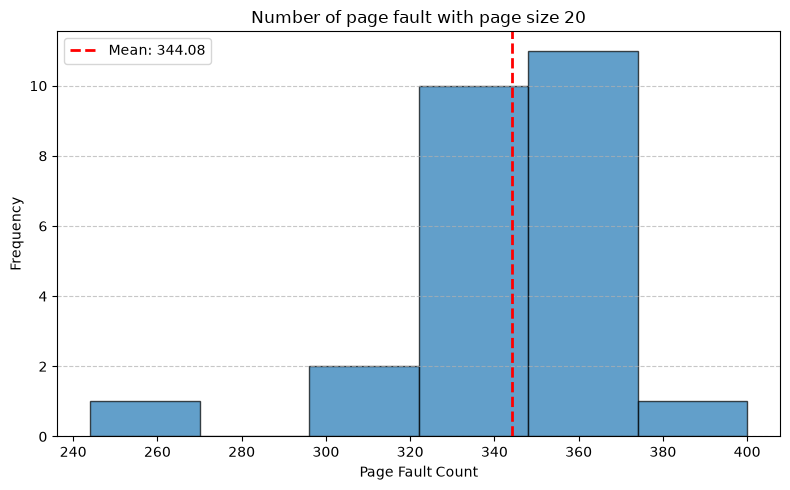

Testing Page size: 24
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 24 KB)

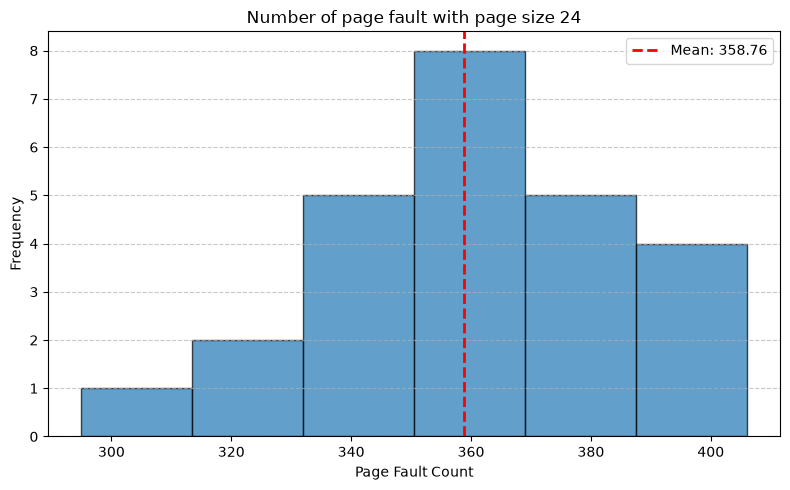

Testing Page size: 32
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 32 KB)

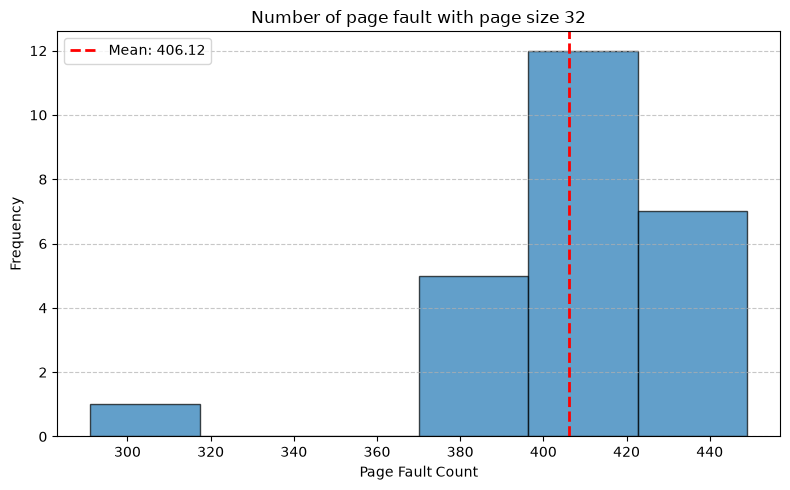

Testing Page size: 64
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 64 KB)

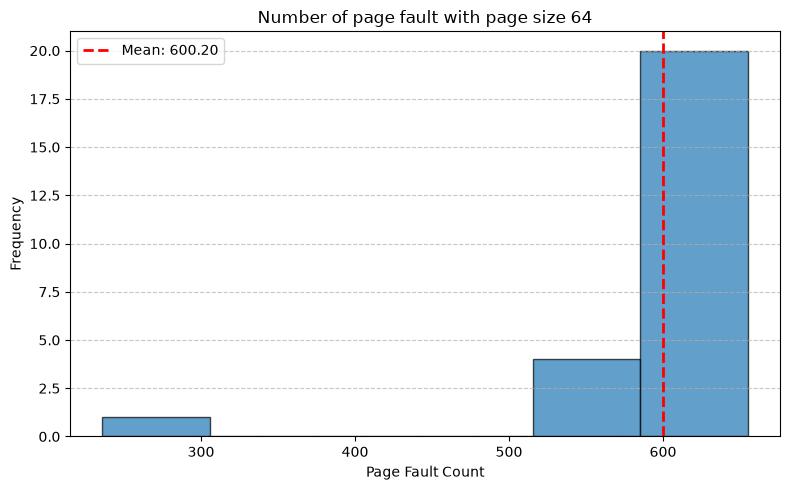

Testing Page size: 96
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 96 KB)

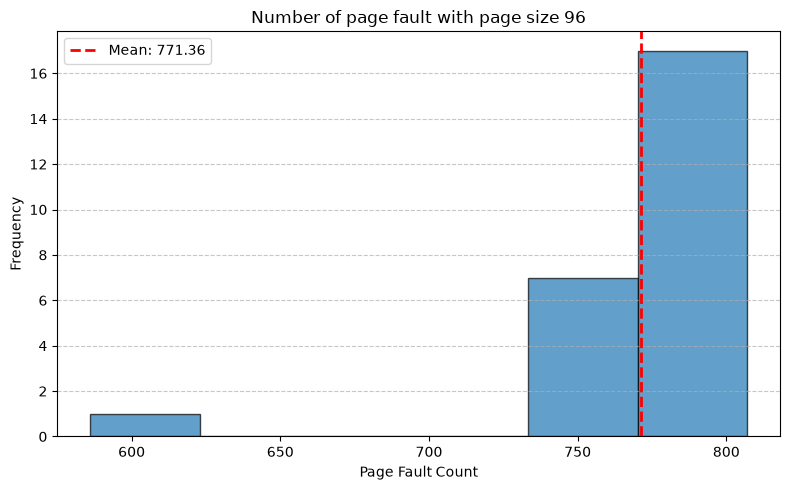

Testing Page size: 128
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 128 KB)

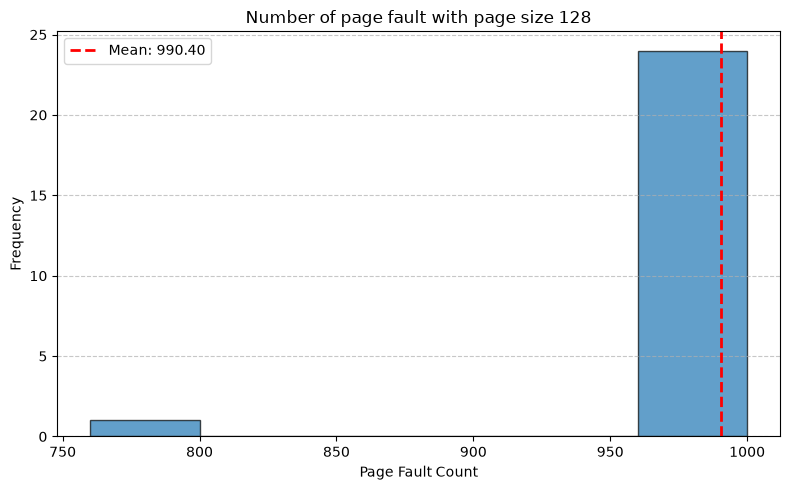

Testing Page size: 256
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 256 KB)

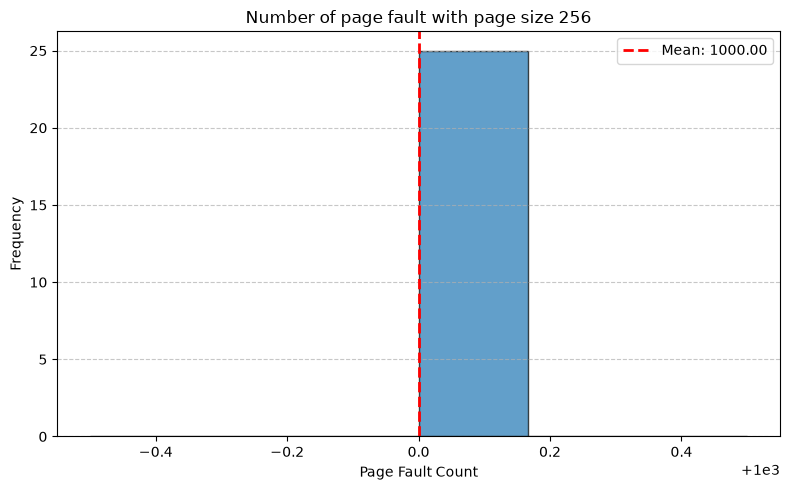

Testing Page size: 384
round 0
round 1
round 2
round 3
round 4
round 5
round 6
round 7
round 8
round 9
round 10
round 11
round 12
round 13
round 14
round 15
round 16
round 17
round 18
round 19
round 20
round 21
round 22
round 23
round 24


## Histogram (Page Size = 384 KB)

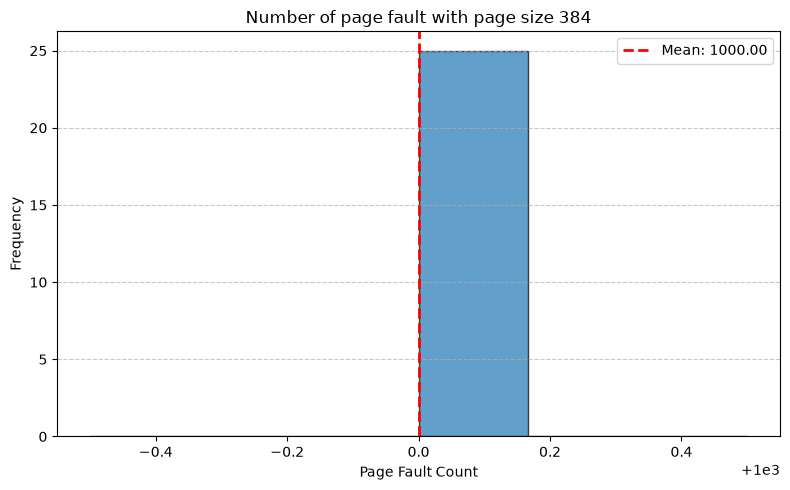

# Mean Page Faults vs Page Sizes

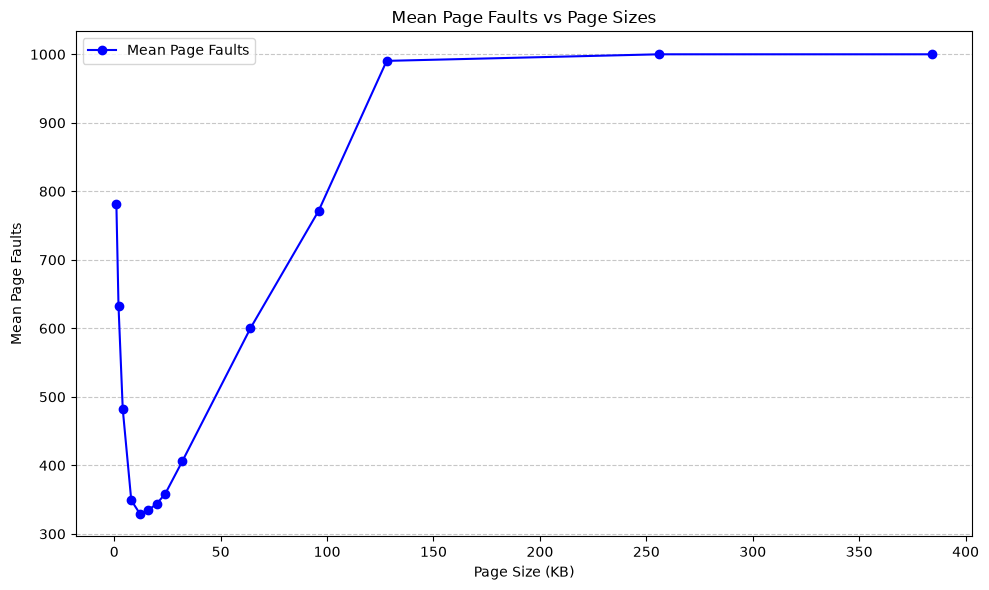

In [2]:
from File import File
from MMU import MMU
from CPU import CPU
from Thread import Thread
import random
import numpy as np
import matplotlib.pyplot as plt 
from IPython.display import display, Markdown
number_of_files = 100
number_of_threads = 20
current = 0
for _ in range(number_of_files):
    rndPage = random.randint(1, 5)
    File(current, current + rndPage * 1000)
    current += rndPage * 1000

mmu1 = MMU()
cpu1 = CPU(mmu1)

for _ in range(number_of_threads):
    cpu1.AddThread(Thread())

mmu1.reset()
cpu1.reset()

mean_pagefaults = []
page_sizes = [1, 2, 4, 8, 12, 16, 20, 24, 32, 64, 96, 128, 256, 384]
for page_size in page_sizes:
    print(f"Testing Page size: {page_size}")
    pagefaults = []
    MMU.page_size = page_size
    for i in range(25):
        print(f"round {i}")
        cpu1.run()
        pagefaults.append(MMU.page_faults)
        mmu1.reset()
        cpu1.reset()

    # Calculate mean
    mean_value = np.mean(pagefaults)
    mean_pagefaults.append(mean_value)
    
    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(pagefaults, bins=6, edgecolor='black', alpha=0.7)

    # Add mean line
    plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')

    # Labels and title
    plt.xlabel("Page Fault Count")
    plt.ylabel("Frequency")
    plt.title(f"Number of page fault with page size {page_size}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()  # Show legend for mean
    display(Markdown(f"## Histogram (Page Size = {page_size} KB)"))
    plt.tight_layout()
    display(plt.gcf())
    plt.savefig(f"pagefaults_histogram{page_size}.png")
    plt.close()
    

# Plot line + bar chart
plt.figure(figsize=(10, 6))

# Line plot for trend
plt.plot(page_sizes, mean_pagefaults, marker='o', linestyle='-', color='blue', label="Mean Page Faults")

# Labels and title
plt.xlabel("Page Size (KB)")
plt.ylabel("Mean Page Faults")
plt.title("Mean Page Faults vs Page Sizes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
display(Markdown("# Mean Page Faults vs Page Sizes"))
plt.tight_layout()

display(plt.gcf())

plt.savefig("mean_pagefaults_vs_page_sizes.png")
plt.close()
